# Análisis salarial del sector IT argentino — Sysarmy 2026
## Parte 2 · La brecha salarial de género

*Realizado en el marco de la Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones (FaMAF, UNC).*

In [15]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

#seaborn.set_context('talk')

## Los datos
Encuesta abierta de Sysarmy (2026), ~4.900 respuestas del sector IT argentino. Aplicamos la misma curación que en la Parte 1.

In [16]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/refs/heads/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)

In [17]:
df[:3]

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0


In [18]:
df.profile_gender.unique()
df.profile_studies_level.describe()


count              1761
unique                7
top       Universitario
freq               1175
Name: profile_studies_level, dtype: object

In [19]:
alpha = 0.05

In [20]:
salary_col = 'salary_monthly_NETO'

# Limpieza global (idéntica a Parte 1)
df = df.dropna(subset=[salary_col])
df = df[df['work_dedication'] != 'Part-Time']

log_sal = np.log10(df[salary_col])
q1, q3 = log_sal.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = 10**(q1 - 1.5 * iqr), 10**(q3 + 1.5 * iqr)
df = df[df[salary_col].between(low, high)].copy()
print(f"df limpio: {len(df)} filas | cotas: ${low:,.0f} – ${high:,.0f}")

df limpio: 4422 filas | cotas: $618,463 – $12,335,410


In [21]:
df['profile_g'] = df.profile_gender.replace({
    'Hombre Cis': 'Varón cis', 'Mujer Cis': 'Mujer cis',
    'Queer': 'Diversidades', 'Trans': 'Diversidades',
    'Lesbiana': 'Diversidades', 'Agénero': 'Diversidades',
})

In [22]:
cols = ['salary_monthly_NETO', 'work_seniority', 'profile_studies_level']
groupA = df[df.profile_g == 'Varón cis'][cols]
groupB = df[df.profile_g == 'Mujer cis'][cols]

In [23]:
print(f"Mean: {groupA['salary_monthly_NETO'].mean()}")
print(f"Median: {groupA['salary_monthly_NETO'].median()}")
print(f"Standard Deviation: {groupA['salary_monthly_NETO'].std()}")

Mean: 3374508.050654179
Median: 2966817.2350000003
Standard Deviation: 1944780.5836043195


In [24]:
print(f"Mean: {groupB['salary_monthly_NETO'].mean()}")
print(f"Median: {groupB['salary_monthly_NETO'].median()}")
print(f"Standard Deviation: {groupB['salary_monthly_NETO'].std()}")

Mean: 2772073.112399077
Median: 2400000.0
Standard Deviation: 1504127.7105222403


Text(0.5, 0, 'Salary')

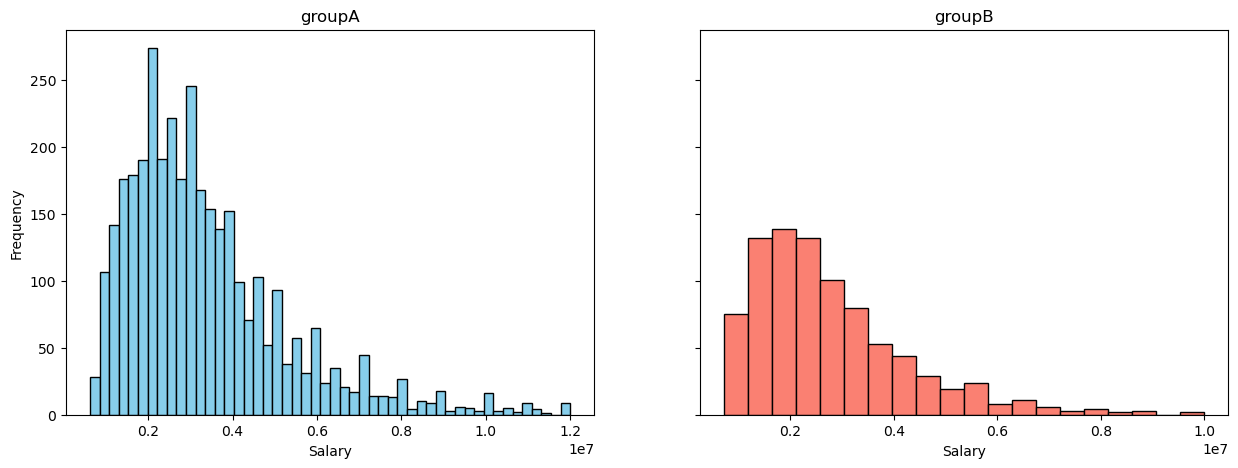

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)  # 1 row, 3 columns

axes[0].hist(groupA['salary_monthly_NETO'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('groupA')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

axes[1].hist(groupB['salary_monthly_NETO'], bins=20, color='salmon', edgecolor='black')
axes[1].set_title('groupB')
axes[1].set_xlabel('Salary')

## Estimación de la brecha y su incertidumbre
Estimamos la diferencia de salario medio entre varones y mujeres (puntual + intervalo de confianza al 95%) y vemos cómo ese intervalo se relaciona con el test de hipótesis.

**Supuestos del cálculo**

1. **Independencia dentro de cada grupo:** cada salario corresponde a un individuo distinto; las observaciones no están correlacionadas entre sí.
2. **Independencia entre grupos:** las muestras de hombres y mujeres son independientes.
3. **Varianzas no necesariamente iguales:** por eso usamos Welch en lugar del t-test con varianza agrupada.
4. **Tamaño muestral suficiente (TCL):** los salarios individuales no son normales (distribución sesgada a derecha). Con muestras grandes en ambos grupos, el Teorema Central del Límite garantiza que las medias muestrales se aproximan a normales; su diferencia, como combinación de dos medias aproximadamente normales, también lo es. Eso es lo que habilita usar el estadístico t/normal sobre la diferencia.

In [ ]:
diff_medias = groupA['salary_monthly_NETO'].mean() - groupB['salary_monthly_NETO'].mean()
print("\n" + "=" * 60)
print("ESTIMACIÓN PUNTUAL")
print("=" * 60)
print(f"Diferencia de medias (Hombres - Mujeres): ${diff_medias:.2f}")


ESTIMACIÓN PUNTUAL
Diferencia de medias (Hombres - Mujeres): $602434.94


In [ ]:
x_h = groupA['salary_monthly_NETO'].mean()
x_m = groupB['salary_monthly_NETO'].mean()
s_h = groupA['salary_monthly_NETO'].std(ddof=1) 
s_m = groupB['salary_monthly_NETO'].std(ddof=1)
n_h = len(groupA)
n_m = len(groupB)


se_diff = np.sqrt((s_h**2 / n_h) + (s_m**2 / n_m))

df_welch = ((s_h**2 / n_h + s_m**2 / n_m)**2) / (
    ((s_h**2 / n_h)**2 / (n_h - 1)) + ((s_m**2 / n_m)**2 / (n_m - 1))
)

t_crit = stats.t.ppf(1 - alpha / 2, df_welch)

margen_error = t_crit * se_diff

ic_inferior = diff_medias - margen_error
ic_superior = diff_medias + margen_error

print("\n" + "=" * 60)
print(f"INTERVALO DE CONFIANZA AL {100*(1-alpha)}%")
print("=" * 60)
print(f"IC: (${ic_inferior:.2f}, ${ic_superior:.2f})")
print(f"Margen de error: ±${margen_error:.2f}")
print(f"Error estándar: ${se_diff:.2f}")
print(f"Grados de libertad (Welch): {df_welch:.2f}")


INTERVALO DE CONFIANZA AL 95.0%
IC: ($483137.74, $721732.14)
Margen de error: ±$119297.20
Error estándar: $60822.87
Grados de libertad (Welch): 1667.90


El IC al 95% para la diferencia de medias es (483.138 ; 721.732) ARS. La relación con el test de dos colas a nivel $α = 0,05$ es de equivalencia exacta: se rechaza $H$₀ si y solo si el IC no contiene al 0 Como el intervalo está completamente por encima de 0, rechazamos $H₀$, y el test formal lo confirma ($p ≈ 1,6·10⁻²²$).

## ¿La brecha es estadísticamente significativa?

### Formalización del test
Planteamos hipótesis, estadístico, distribución bajo H₀ y región de rechazo para contrastar si los salarios difieren entre varones y mujeres.


### 2.1 Formalización

Describir formalmente los distintos componentes de un test de hipótesis para comprobar si la distribución de los salarios es distinta entre los grupos A (hombres) y B (mujeres).

**Hipótesis Nula**

$H_0: \mu_A - \mu_B = 0 $ (No existe brecha salarial)

$H_1: \mu_A - \mu_B \neq 0 $ (Existe brecha salarial)

**Estadístico (Pivote)**
  * Identificar el estadístico:

    Como se tienen varianzas distintas, usamos el **Test de Welch**:

    Sean dos muestras $\bar{X_1}$ y $\bar{X_2}$, el Test de Welch se define como:
    $$
      t
      =
      \frac{\Delta \bar{X}}{s_{\Delta \bar{X}}}
      =
      \frac{\bar{X_1}-\bar{X_2}}{\sqrt{s^2_{\bar{X_1}}+s^2_{\bar{X_2}}}}
    $$

  * Escribir qué distribución tiene bajo $H_0$:

  Bajo $H_0$, el estadístico $t$ sigue aproximadamente una distribución $t$ de Student con $\nu$ grados de libertad dados por la fórmula de Welch-Satterthwaite:

  $$\nu = \frac{\left(\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}\right)^2}{\frac{\left(\frac{s_A^2}{n_A}\right)^2}{n_A - 1} + \frac{\left(\frac{s_B^2}{n_B}\right)^2}{n_B - 1}}$$

  Región de rechazo (nivel $\alpha = 0.05$):

  Se rechaza $H_0$ si $|t| > t_{\alpha/2, \nu}$, o equivalentemente, si el $p$-valor $< \alpha$.

### P-valor y decisión
Calculamos el p-valor con el test de Welch y decidimos sobre H₀.

In [ ]:
from scipy.stats import ttest_ind

print("\n" + "=" * 70)
print("CÁLCULO DEL P-VALOR Y DECISIÓN")
print("=" * 70)

t_statistic, p_value = ttest_ind(groupA['salary_monthly_NETO'], groupB['salary_monthly_NETO'], equal_var=False)

print(f"\nEstadístico t calculado: {t_statistic:.4f}")
print(f"P-valor (two-tailed): {p_value}")
print(f"Nivel de significancia α: {alpha}")

print("\n" + "-" * 70)
print("DECISIÓN:")
print("-" * 70)

if p_value < alpha:
    print(f"\n✓ p-valor ({p_value}) < α ({alpha})")
    print("\n→ RECHAZAMOS la hipótesis nula")
    print("\n CONCLUSIÓN:")
    print("   Hay EVIDENCIA ESTADÍSTICAMENTE SIGNIFICATIVA de que existe")
    print("   una diferencia en los salarios netos entre hombres y mujeres.")
else:
    print(f"\n✗ p-valor ({p_value}) ≥ α ({alpha})")
    print("\n→ NO RECHAZAMOS la hipótesis nula")
    print("\nCONCLUSIÓN:")
    print("   No hay evidencia suficiente para afirmar que existe")
    print("   una diferencia significativa en los salarios entre grupos.")


CÁLCULO DEL P-VALOR Y DECISIÓN

Estadístico t calculado: 9.9047
P-valor (two-tailed): 1.6372004461743615e-22
Nivel de significancia α: 0.05

----------------------------------------------------------------------
DECISIÓN:
----------------------------------------------------------------------

✓ p-valor (1.6372004461743615e-22) < α (0.05)

→ RECHAZAMOS la hipótesis nula

 CONCLUSIÓN:
   Hay EVIDENCIA ESTADÍSTICAMENTE SIGNIFICATIVA de que existe
   una diferencia en los salarios netos entre hombres y mujeres.


#### Interpretación del resultado

Los hombres ganan en promedio $ $602.435$ más que las mujeres
(con una confianza del $95.0\%$)

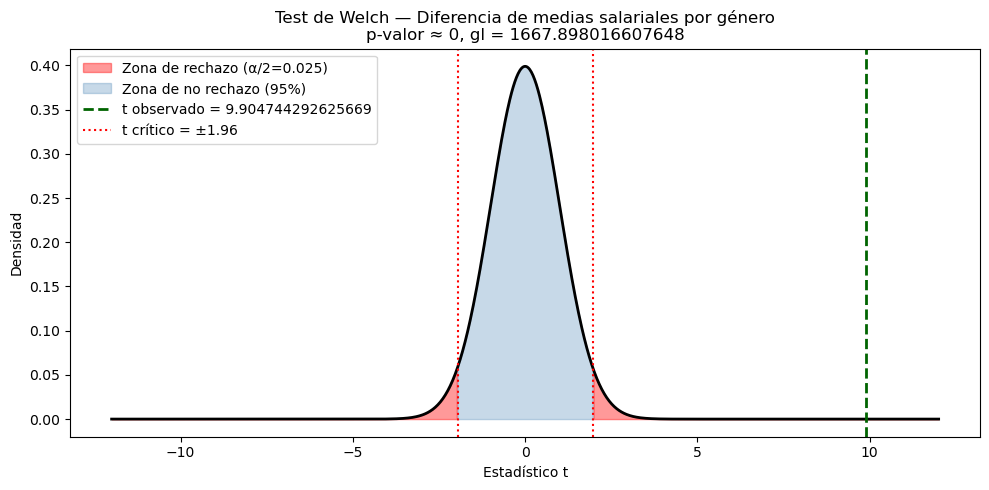

In [ ]:

t_observado = t_statistic

x = np.linspace(-12, 12, 1000)
y = stats.t.pdf(x, df=df_welch)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, y, color='black', linewidth=2)

ax.fill_between(x, y, where=(x <= -t_crit), color='red', alpha=0.4, label=f'Zona de rechazo (α/2=0.025)')
ax.fill_between(x, y, where=(x >= t_crit), color='red', alpha=0.4)

ax.fill_between(x, y, where=(x > -t_crit) & (x < t_crit), color='steelblue', alpha=0.3, label='Zona de no rechazo (95%)')

ax.axvline(t_observado, color='darkgreen', linestyle='--', linewidth=2, label=f't observado = {t_observado}')

ax.axvline(t_crit, color='red', linestyle=':', linewidth=1.5, label=f't crítico = ±{t_crit:.2f}')
ax.axvline(-t_crit, color='red', linestyle=':', linewidth=1.5)

ax.set_title(f'Test de Welch — Diferencia de medias salariales por género\np-valor ≈ 0, gl = {df_welch}')
ax.set_xlabel('Estadístico t')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

### Potencia del test
¿La muestra era suficientemente grande para detectar la diferencia? Calculamos el n necesario para potencias de 0,8 / 0,9 / 0,95 y lo comparamos con el n disponible.

In [ ]:
from statsmodels.stats.power import tt_ind_solve_power

In [ ]:
effect_size = (groupA['salary_monthly_NETO'].mean() - groupB['salary_monthly_NETO'].mean()) / groupB['salary_monthly_NETO'].std()
alpha = 0.05
ratio = len(groupB) / len(groupA)
power = 0.8

In [32]:
for i in [0.8, 0.9, 0.95]:
    nA_necesario = tt_ind_solve_power(effect_size=effect_size, alpha=alpha,power=i,  ratio=ratio)
    nB_necesario = nA_necesario * ratio
    print("\n" + "=" * 60)
    print("Poder estadístico de " + str(i))
    print("=" * 60)
    print(f"n necesario groupA (hombres): {nA_necesario:.0f}")
    print(f"n necesario groupB (mujeres): {nB_necesario:.0f}")
    print(f"n total necesario: {nA_necesario + nB_necesario:.0f}")

print("\n" + "=" * 60)
print(f"Tamaño de grupo A (hombres): {len(groupA)}")
print(f"Tamaño de grupo B (mujeres): {len(groupB)}")
print("=" * 60)


Poder estadístico de 0.8
n necesario groupA (hombres): 246
n necesario groupB (mujeres): 62
n total necesario: 308

Poder estadístico de 0.9
n necesario groupA (hombres): 329
n necesario groupB (mujeres): 82
n total necesario: 411

Poder estadístico de 0.95
n necesario groupA (hombres): 407
n necesario groupB (mujeres): 102
n total necesario: 508

Tamaño de grupo A (hombres): 3470
Tamaño de grupo B (mujeres): 867


**Interpretación del poder estadístico**

El poder estadístico indica la probabilidad de detectar una diferencia del tamaño observado si este realmente existe.

**¿Esta muestra es lo suficientemente representativa de la tendencia general?**

En nuestro caso, si la brecha salarial es real, es práctiamente seguro que nuestro test la detectaría debido a la gran cantidad de datos disponibles en comparación a los necesarios. Sin embargo, hay que tener en cuenta que esta es una encuesta voluntaria que podría estar sesgada.

**¿Para utilizarlo en un juicio penal contra una empresa XX por una causa de discriminación?**

No directamente, ya que relación no implica causalidad. Es decir, si bien el salario y género están relacionados, no prueba que exista una discriminación explícita. Además, aún asumiendo que ésta relación implica discriminación, los datos manejados no pertenecen a la empresa imputada, sino de una encuesta abierta. 


### Interpretación del resultado

*Ya que el p-valor es prácticamente nulo, esto indica que la probabilidad de observar una diferencia de medias tan extrema (o más) entre hombres y mujeres, asumiendo que no hay diferencia real (hipótesis nula), es extremadamente baja. Por lo tanto, rechazamos la hipótesis nula y concluimos que existe una diferencia estadísticamente significativa en los salarios netos entre hombres y mujeres en esta muestra.*

## Visualización de resultados
Distintas representaciones de la brecha: por percentil, promedios con intervalo de confianza, distribución (box/violín) y desagregada por seniority.

In [ ]:
plt.rcParams.update({
    'font.size': 14,           
    'axes.titlesize': 17,      
    'axes.labelsize': 15,      
    'xtick.labelsize': 12,     
    'ytick.labelsize': 12,     
    'legend.fontsize': 16,     
    'figure.titlesize': 18    
})

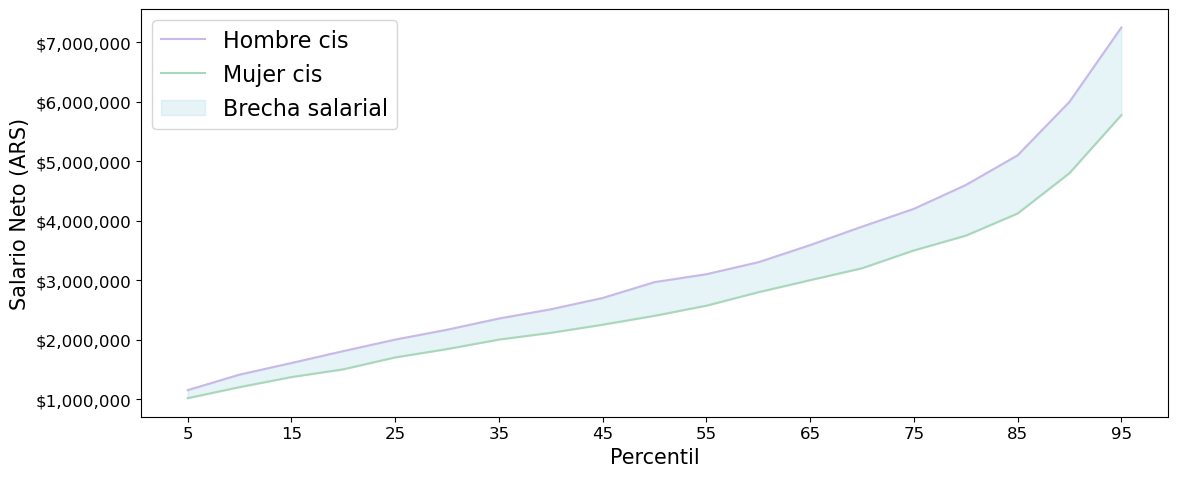

In [ ]:
percentiles = np.arange(5, 100, 5)

color_hombres = '#C9B8E8'
color_mujeres = '#A8D8B9'


p_hombres = np.percentile(groupA['salary_monthly_NETO'], percentiles)
p_mujeres = np.percentile(groupB['salary_monthly_NETO'], percentiles)

brecha_p = p_hombres - p_mujeres

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(percentiles, p_hombres, color=color_hombres, label='Hombre cis')
ax.plot(percentiles, p_mujeres, color=color_mujeres, label='Mujer cis')

ax.fill_between(percentiles, p_hombres, p_mujeres, 
                alpha=0.3, color='lightblue', label='Brecha salarial')

ax.set_xticks(np.arange(5, 100, 10))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlabel('Percentil')
ax.set_ylabel('Salario Neto (ARS)')
ax.legend()
plt.tight_layout()
plt.savefig('grafico_percentil_brecha.pdf')
plt.show()


/tmp/ipykernel_1276/3776030829.py:3: UserWarning: 
The palette list has fewer values (2) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df, x='profile_g', y='salary_monthly_NETO',


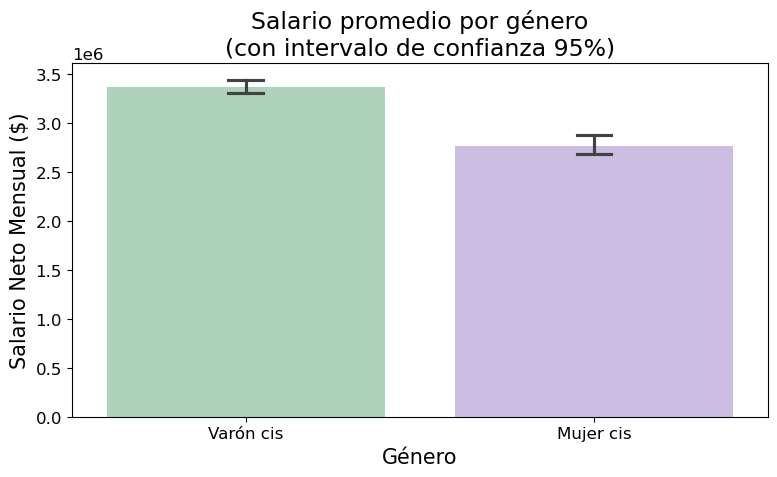

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=df, x='profile_g', y='salary_monthly_NETO',
            hue='profile_g',
            order=['Varón cis', 'Mujer cis'],
            palette=[color_hombres, color_mujeres],
            capsize=0.1,
            legend=False
            )

ax.set_title('Salario promedio por género\n(con intervalo de confianza 95%)')
ax.set_xlabel('Género')
ax.set_ylabel('Salario Neto Mensual ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1276/2713273223.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


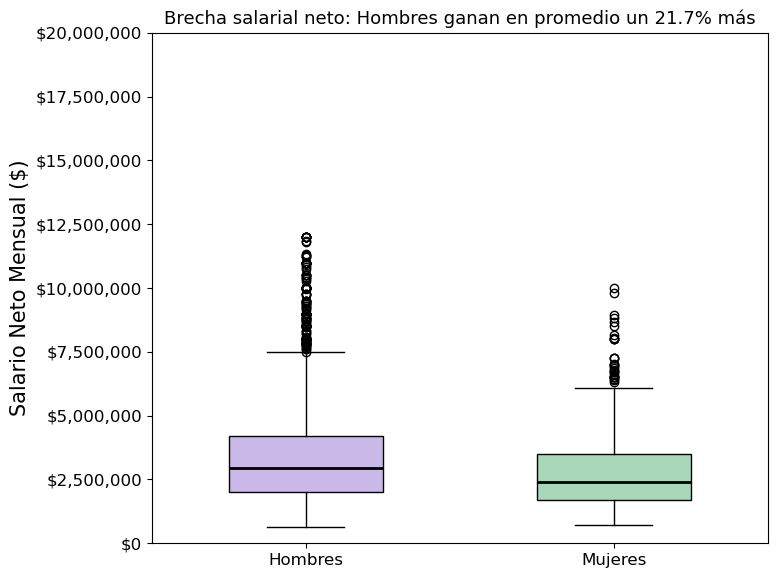

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    [groupA['salary_monthly_NETO'], groupB['salary_monthly_NETO']],
    labels=['Hombres', 'Mujeres'],
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)

bp['boxes'][0].set_facecolor(color_hombres)
bp['boxes'][1].set_facecolor(color_mujeres)

# Anotación con la diferencia
diff_pct = (groupA['salary_monthly_NETO'].mean() - groupB['salary_monthly_NETO'].mean()) / groupB['salary_monthly_NETO'].mean() * 100

ax.set_title(f'Brecha salarial neto: Hombres ganan en promedio un {diff_pct:.1f}% más', fontsize=13)
ax.set_ylabel('Salario Neto Mensual ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.ylim(0, 20000000)
plt.tight_layout()
plt.show()

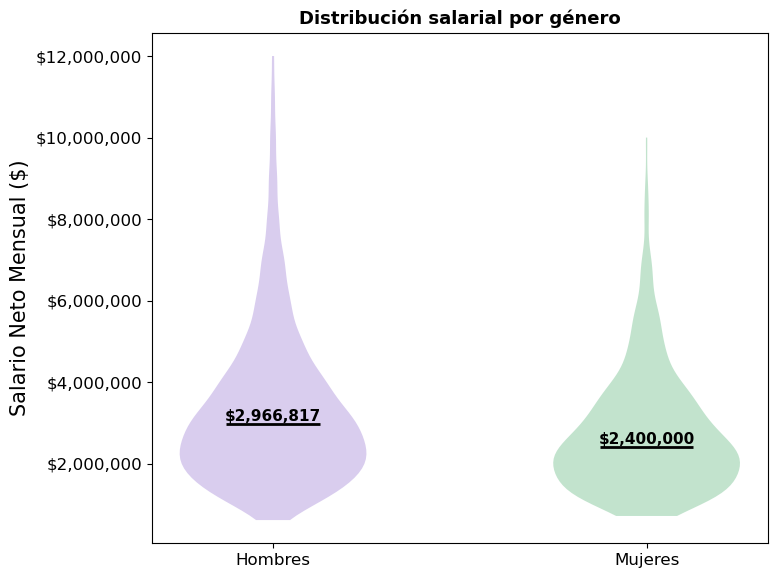

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

vp = ax.violinplot([groupA['salary_monthly_NETO'], groupB['salary_monthly_NETO']], positions=[1, 2], showmedians=True, showextrema=False)
vp['bodies'][0].set_facecolor(color_hombres)
vp['bodies'][0].set_alpha(0.7)
vp['bodies'][1].set_facecolor(color_mujeres)
vp['bodies'][1].set_alpha(0.7)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(2)

for pos, grupo in [(1, groupA), (2, groupB)]:
    ax.text(pos, grupo['salary_monthly_NETO'].median(), f'${grupo["salary_monthly_NETO"].median():,.0f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Hombres', 'Mujeres'])
ax.set_ylabel('Salario Neto Mensual ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Distribución salarial por género', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Brecha por seniority
Comparamos la brecha dentro de cada nivel de seniority, primero en crudo y luego fijando nivel de estudios (Universitario).

In [38]:
groupA_sub = groupA[groupA['profile_studies_level'].isin(['Universitario'])]
groupB_sub = groupB[groupB['profile_studies_level'].isin(['Universitario'])]

seniority = ['Junior', 'Semi-Senior', 'Senior']

media_hombre = []
for s in seniority:
    media = groupA_sub[groupA_sub['work_seniority'] == s]['salary_monthly_NETO'].mean()
    print(f"Varón cis - {s}: {media:,.0f}")
    media_hombre.append(media)

media_mujer = []
for s in seniority:
    media = groupB_sub[groupB_sub['work_seniority'] == s]['salary_monthly_NETO'].mean()
    print(f"Mujer cis - {s}: {media:,.0f}")
    media_mujer.append(media)

brechas = [(h - m) / h * 100 for h, m in zip(media_hombre, media_mujer)]


Varón cis - Junior: 1,804,480
Varón cis - Semi-Senior: 2,723,927
Varón cis - Senior: 4,269,499
Mujer cis - Junior: 1,832,591
Mujer cis - Semi-Senior: 2,557,189
Mujer cis - Senior: 3,498,230


Brecha salarial en Junior: -1.56%
Brecha salarial en Semi-Senior: 6.12%
Brecha salarial en Senior: 18.06%


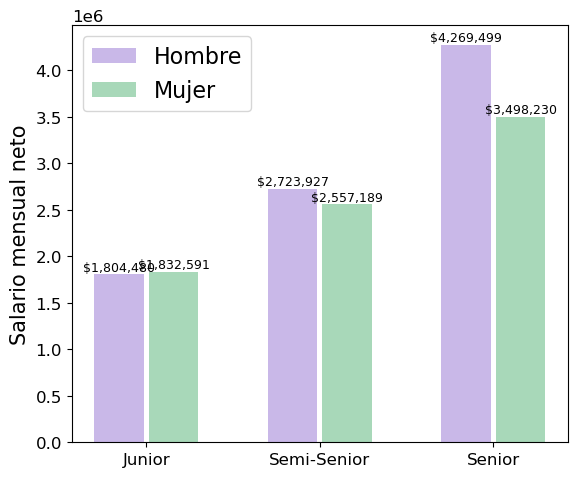

In [ ]:
for s, b in zip(seniority, brechas):
    print(f"Brecha salarial en {s}: {b:.2f}%")
    
fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(seniority))*0.7 
width = 0.2

bars_h = ax.bar(x - width/2 - 0.01, 
                media_hombre, 
                width, 
                color='#C9B8E8', 
                label='Hombre'
                )

bars_m = ax.bar(x + width/2 + 0.01, 
                media_mujer, 
                width, 
                color='#A8D8B9',
                label='Mujer'
                  )

for bar in bars_h:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 40000,
            f'${bar.get_height():,.0f}', 
            ha='center', 
            fontsize=9
            )

for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 40000,
            f'${bar.get_height():,.0f}', 
            ha='center', 
            fontsize=9
            )


ax.set_xticks(x)
ax.set_xticklabels(seniority)
ax.legend()
ax.set_ylabel('Salario mensual neto')
plt.tight_layout()
plt.show()

Varón cis - Junior: 1,797,832
Varón cis - Semi-Senior: 2,676,998
Varón cis - Senior: 3,949,396
Mujer cis - Junior: 1,728,725
Mujer cis - Semi-Senior: 2,341,700
Mujer cis - Senior: 3,422,494
Brecha salarial en Junior: 3.84%
Brecha salarial en Semi-Senior: 12.53%
Brecha salarial en Senior: 13.34%


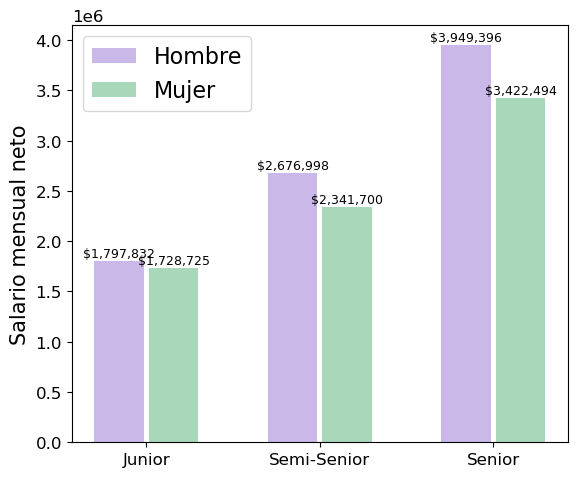

In [ ]:
media_hombre = []
for s in seniority:
    media = groupA[groupA['work_seniority'] == s]['salary_monthly_NETO'].mean()
    print(f"Varón cis - {s}: {media:,.0f}")
    media_hombre.append(media)

media_mujer = []
for s in seniority:
    media = groupB[groupB['work_seniority'] == s]['salary_monthly_NETO'].mean()
    print(f"Mujer cis - {s}: {media:,.0f}")
    media_mujer.append(media)

brechas = [(h - m) / h * 100 for h, m in zip(media_hombre, media_mujer)]
for s, b in zip(seniority, brechas):
    print(f"Brecha salarial en {s}: {b:.2f}%")
    
fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(seniority))*0.7 
width = 0.2

bars_h = ax.bar(x - width/2 - 0.01, 
                media_hombre, 
                width, 
                color='#C9B8E8', 
                label='Hombre'
                )

bars_m = ax.bar(x + width/2 + 0.01, 
                media_mujer, 
                width, 
                color='#A8D8B9',
                label='Mujer'
                  )

# Etiquetas de valor arriba de cada barra
for bar in bars_h:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 40000,
            f'${bar.get_height():,.0f}', 
            ha='center', 
            fontsize=9
            )

for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 40000,
            f'${bar.get_height():,.0f}', 
            ha='center', 
            fontsize=9
            )


ax.set_xticks(x)
ax.set_xticklabels(seniority)
ax.legend()
ax.set_ylabel('Salario mensual neto')
plt.tight_layout()
plt.show()

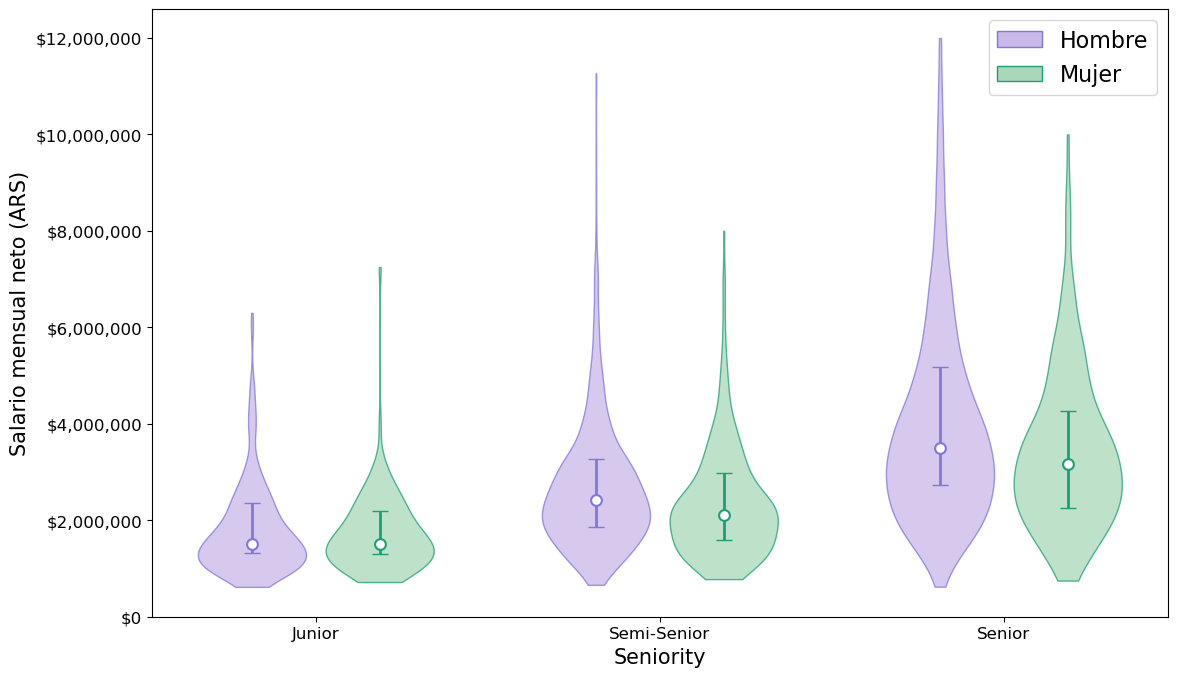

In [ ]:
import matplotlib.patches as mpatches

datos_h = [groupA[groupA['work_seniority']==s]['salary_monthly_NETO'].values for s in seniority] 
datos_m = [groupB[groupB['work_seniority']==s]['salary_monthly_NETO'].values  for s in seniority] 


EDGE_H   = '#7F77DD'
EDGE_M   = '#1D9E75'

x      = np.arange(len(seniority)) * 0.7
offset = 0.13   

fig, ax = plt.subplots(figsize=(12, 7))

for i, s in enumerate(seniority):

    
    vp_h = ax.violinplot(
        datos_h[i],
        positions=[x[i] - offset],
        widths=0.22,
        showmedians=False,   
        showextrema=False,
    )
    for pc in vp_h['bodies']:
        pc.set_facecolor(color_hombres)
        pc.set_edgecolor(EDGE_H)
        pc.set_alpha(0.75)

    
    vp_m = ax.violinplot(
        datos_m[i],
        positions=[x[i] + offset],
        widths=0.22,
        showmedians=False,
        showextrema=False,
    )
    for pc in vp_m['bodies']:
        pc.set_facecolor(color_mujeres)
        pc.set_edgecolor(EDGE_M)
        pc.set_alpha(0.75)

    
    med_h = np.median(datos_h[i])
    med_m = np.median(datos_m[i])

    ax.scatter([x[i] - offset], [med_h], color='white', edgecolors=EDGE_H,
               s=60, zorder=5, linewidths=1.5)
    ax.scatter([x[i] + offset], [med_m], color='white', edgecolors=EDGE_M,
               s=60, zorder=5, linewidths=1.5)

   
    q1_h, q3_h = np.percentile(datos_h[i], [25, 75])
    q1_m, q3_m = np.percentile(datos_m[i], [25, 75])

    ax.errorbar(x[i] - offset, (q1_h + q3_h) / 2,
                yerr=[[med_h - q1_h], [q3_h - med_h]],
                fmt='none', color=EDGE_H, linewidth=2, capsize=6, zorder=4)

    ax.errorbar(x[i] + offset, (q1_m + q3_m) / 2,
                yerr=[[med_m - q1_m], [q3_m - med_m]],
                fmt='none', color=EDGE_M, linewidth=2, capsize=6, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(seniority)
ax.set_xlabel('Seniority')
ax.set_ylabel('Salario mensual neto (ARS)')
ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--', alpha=0.4)

leyenda = [
    mpatches.Patch(facecolor=color_hombres, edgecolor=EDGE_H, label='Hombre'),
    mpatches.Patch(facecolor=color_mujeres, edgecolor=EDGE_M, label='Mujer'),
]
ax.legend(handles=leyenda)

ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('grafico_gota_seniority.pdf')
plt.show()

## ¿De dónde viene la brecha?

La diferencia de medias (~602.000 ARS, ~18% en niveles) es el titular, pero no distingue si las mujeres ganan menos por estar sub-representadas en los puestos mejor pagos, o si ganan menos *a igual puesto*. Para separarlo, descomponemos la brecha en miradas de granularidad creciente.

### Brecha cruda

En promedio las mujeres ganan ~18% menos que los varones. El gráfico por percentil muestra que la brecha no es uniforme: es chica en los percentiles bajos y se ensancha en los altos.

### Brecha por seniority

Comparando dentro de cada nivel, la brecha no desaparece: es prácticamente nula en Junior y crece hasta ~13% en Senior (y hasta ~18% si además fijamos nivel de estudios universitario). Esto ya descarta que la brecha sea sólo composición: a igual seniority persiste, y se agranda con la jerarquía.



In [42]:
import statsmodels.formula.api as smf

reg_df = df[df.profile_g.isin(['Varón cis', 'Mujer cis'])].copy()
reg_df['log_salary'] = np.log(reg_df['salary_monthly_NETO'])

model = smf.ols(
    'log_salary ~ C(profile_g, Treatment("Varón cis")) '
    '+ C(work_seniority) + profile_age + C(work_work_modality)',
    data=reg_df
).fit()
print(model.summary())

coef = model.params.filter(like='Mujer cis').iloc[0]
print(f"\nBrecha ajustada (mujer vs varón, a igual seniority/edad/modalidad): "
      f"{(np.exp(coef) - 1) * 100:.1f}%")

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     259.0
Date:                Tue, 02 Jun 2026   Prob (F-statistic):          8.19e-284
Time:                        12:33:04   Log-Likelihood:                -2866.8
No. Observations:                4337   AIC:                             5748.
Df Residuals:                    4330   BIC:                             5792.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

### Brecha ajustada (regresión)

Una regresión de log(salario) que controla seniority, edad y modalidad de forma simultánea estima la brecha neta de esos factores en −11,6% (IC 95%: −14,7% a −8,4%). Es decir: de la brecha cruda de ~18%, una parte se explica por composición (las mujeres están menos representadas en seniority alto y en las modalidades mejor pagas), pero persiste una brecha de ~12% comparando personas en la misma posición, edad y modalidad. Los residuos del modelo son aproximadamente normales (Jarque-Bera p = 0,93), lo que valida el uso de la escala logarítmica. Limitación: es una asociación, no una relación causal; quedan factores no observados (rol específico, empresa, antigüedad).